# **1. Cài Đặt & Import Thư Viện**

In [1]:
!pip install -q ucimlrepo scikit-learn seaborn joblib

In [2]:
import os
import json
import joblib
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)

# **2. Thiết Lập Tham Số Chung**

In [13]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
THRESHOLD = 0.5

OUTPUT_MODEL_DIR = "outputs/models"
OUTPUT_TABLE_DIR = "outputs/tables"
OUTPUT_FIG_DIR = "outputs/figures"

os.makedirs(OUTPUT_MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_TABLE_DIR, exist_ok=True)
os.makedirs(OUTPUT_FIG_DIR, exist_ok=True)

print("Đã khởi tạo các folder output.")

Đã khởi tạo các folder output.


# **3. Tải Dataset Từ UCI**

In [14]:
student_performance = fetch_ucirepo(id=320)

X = student_performance.data.features
y_original = student_performance.data.targets

df = pd.concat([X, y_original], axis=1)

print(f"Kích thước dataset:\n- Hàng: {df.shape[0]}\n- Cột: {df.shape[1]}")
print('Preview dataset:')
display(df.head())

Kích thước dataset:
- Hàng: 649
- Cột: 33
Preview dataset:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


Quick Check Dataset:

In [32]:
print("Số trường thuộc tính:")
print("; ".join(df.columns.tolist()))

print("\nKiểu dữ liệu của các thuộc tính:")
print("; ".join([f"{{{col}, {dtype}}}" for col, dtype in df.dtypes.items()]))

print("\nGiá trị missing của các thuộc tính:")
missing = df.isnull().sum().sort_values(ascending=False).head(20)
print("; ".join([f"{{{col}, {val}}}" for col, val in missing.items()]))

print("\nGiá trị trùng lặp của các thuộc tính:")
print(f"{{duplicated_rows, {df.duplicated().sum()}}}")

Số trường thuộc tính:
school; sex; age; address; famsize; Pstatus; Medu; Fedu; Mjob; Fjob; reason; guardian; traveltime; studytime; failures; schoolsup; famsup; paid; activities; nursery; higher; internet; romantic; famrel; freetime; goout; Dalc; Walc; health; absences; G1; G2; G3; pass

Kiểu dữ liệu của các thuộc tính:
{school, object}; {sex, object}; {age, int64}; {address, object}; {famsize, object}; {Pstatus, object}; {Medu, int64}; {Fedu, int64}; {Mjob, object}; {Fjob, object}; {reason, object}; {guardian, object}; {traveltime, int64}; {studytime, int64}; {failures, int64}; {schoolsup, object}; {famsup, object}; {paid, object}; {activities, object}; {nursery, object}; {higher, object}; {internet, object}; {romantic, object}; {famrel, int64}; {freetime, int64}; {goout, int64}; {Dalc, int64}; {Walc, int64}; {health, int64}; {absences, int64}; {G1, int64}; {G2, int64}; {G3, int64}; {pass, int64}

Giá trị missing của các thuộc tính:
{school, 0}; {sex, 0}; {age, 0}; {address, 0}; {fams

# **4. Tạo Target PASS/FAIL Từ G3 (Điểm Cuối Kì)**

* if G3 >= 10 → pass = 1 (PASS)

* if G3 < 10 → pass = 0 (FAIL)

In [30]:
df["pass"] = (df["G3"] >= 10).astype(int)

print(f"Phân bổ số lượng sinh viên trong dataset:\n- PASS: {df['pass'].value_counts()[1]} sinh viên\n- FAIL: {df['pass'].value_counts()[0]} sinh viên")

print(f"Tỷ lệ phần trăm phân bổ số lượng sinh viên trong dataset:\n- PASS: {(df['pass'].value_counts(normalize=True)[1]*100).round(2)} %\n- FAIL: {(df['pass'].value_counts(normalize=True)[0]*100).round(2)} %")

Phân bổ số lượng sinh viên trong dataset:
- PASS: 549 sinh viên
- FAIL: 100 sinh viên
Tỷ lệ phần trăm phân bổ số lượng sinh viên trong dataset:
- PASS: 84.59 %
- FAIL: 15.41 %


**4. Tách Feature & Target, Loại G3**

G3 chứa thông tin trực tiếp về label. Nếu giữ G3 trong feature thì model sẽ biết luôn đáp án, dẫn đến kết quả dự đoán gần như 100% nhưng không có ý nghĩa thực tế.

Ví dụ:

* G3 = 12 → pass = 1.

* G3 = 8  → pass = 0.

Nếu model nhìn thấy G3 thì nó chỉ cần học:

if G3 >= 10 → pass

→ độ chính xác gần 100% nhưng vô nghĩa.

Vì vậy G3 bắt buộc phải loại bỏ.

In [33]:
X_raw = df.drop(columns=["pass", "G3"], errors="ignore")
y = df["pass"].astype(int)

print("Shape X_raw:", X_raw.shape)
print("Shape y:", y.shape)

display(X_raw.head())

Shape X_raw: (649, 32)
Shape y: (649,)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,4,3,4,1,1,3,4,0,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,no,5,3,3,1,1,3,2,9,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,no,4,3,2,2,3,3,6,12,13
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,3,2,2,1,1,5,0,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,4,3,2,1,2,5,0,11,13


# **5. Tách Cột Số Và Cột Phân Loại**

In [34]:
numeric_features = X_raw.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_raw.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print("Số đặc trưng số:", len(numeric_features))
print("Số đặc trưng phân loại:", len(categorical_features))

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Số đặc trưng số: 15
Số đặc trưng phân loại: 17

Numeric features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']

Categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


# **6. Train/Test Split**

In [35]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train_raw:", X_train_raw.shape)
print("X_test_raw :", X_test_raw.shape)
print("y_train    :", y_train.shape)
print("y_test     :", y_test.shape)

X_train_raw: (519, 32)
X_test_raw : (130, 32)
y_train    : (519,)
y_test     : (130,)


# **7. Preprocessing Pipeline**

In [36]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Đã tạo xong preprocessor.")

Đã tạo xong preprocessor.


# **8. Model Pipeline Hoàn Chỉnh**

In [37]:
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

print(model_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'Medu', 'Fedu',
                                                   'traveltime', 'studytime',
                                                   'failures', 'famrel',
                                                   'freetime', 'goout', 'Dalc',
                                                   'Walc', 'health', 'absences',
                                                   'G1', 'G2']),
                                                 ('cat',
                                                  Pipelin

# **9. Training Pipeline**

In [38]:
model_pipeline.fit(X_train_raw, y_train)

print("Huấn luyện pipeline hoàn tất.")

Huấn luyện pipeline hoàn tất.


# **10. Dự Đoán Trên Tập Test**

In [41]:
# Copy lại dữ liệu test
results_df = X_test_raw.copy()

# Thêm nhãn thật
results_df["actual"] = y_test.values

# Thêm dự đoán
results_df["pred_label"] = y_pred

# Thêm xác suất
results_df["pred_proba_pass"] = y_proba

# Map cho dễ đọc
results_df["actual_name"] = results_df["actual"].map({0: "Fail", 1: "Pass"})
results_df["pred_name"] = results_df["pred_label"].map({0: "Fail", 1: "Pass"})

# Hiển thị 20 dòng đầu
display(results_df.head(20))

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,Walc,health,absences,G1,G2,actual,pred_label,pred_proba_pass,actual_name,pred_name
28,GP,M,16,U,LE3,A,3,4,services,other,...,1,5,2,12,12,1,1,0.996390,Pass,Pass
124,GP,F,16,U,GT3,T,2,2,other,other,...,1,5,0,12,11,1,1,0.990611,Pass,Pass
135,GP,F,16,U,GT3,A,3,4,services,other,...,4,5,12,15,13,1,1,0.999933,Pass,Pass
641,MS,F,18,R,GT3,T,2,2,at_home,other,...,3,4,0,14,17,1,1,0.999998,Pass,Pass
552,MS,M,19,U,GT3,T,1,1,other,other,...,4,4,2,9,9,1,0,0.272976,Pass,Fail
570,MS,M,16,R,GT3,T,2,2,services,services,...,4,4,6,7,8,0,0,0.018191,Fail,Fail
502,MS,M,17,R,LE3,T,2,2,services,services,...,5,3,2,10,8,0,0,0.405948,Fail,Fail
410,GP,F,17,U,GT3,T,2,2,services,services,...,3,4,0,13,17,1,1,0.999999,Pass,Pass
596,MS,F,17,U,GT3,T,4,2,other,other,...,2,4,0,17,18,1,1,1.000000,Pass,Pass
324,GP,M,18,U,GT3,T,1,2,at_home,other,...,4,4,10,10,10,1,1,0.953934,Pass,Pass


# **11. Đánh Giá Hiệu Quả Model**

# ***11.1. Tính Metrics đánh giá***

In [58]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, y_proba)

print("Metrics: ")

metrics = {
    "- Accuracy": acc,
    "- Precision": prec,
    "- Recall": rec,
    "- F1-score": f1,
    "- PR-AUC": pr_auc
}

print("\n".join([f"{k}: {v:.6f}" for k, v in metrics.items()]))

Metrics: 
- Accuracy: 0.907692
- Precision: 0.945455
- Recall: 0.945455
- F1-score: 0.945455
- PR-AUC: 0.986107


# ***11.2. Classification report***

In [60]:
print("Classification Report: ")
print(classification_report(y_test, y_pred, target_names=["Fail", "Pass"]))

Classification Report: 
              precision    recall  f1-score   support

        Fail       0.70      0.70      0.70        20
        Pass       0.95      0.95      0.95       110

    accuracy                           0.91       130
   macro avg       0.82      0.82      0.82       130
weighted avg       0.91      0.91      0.91       130



# ***11.3. Confusion matrix***

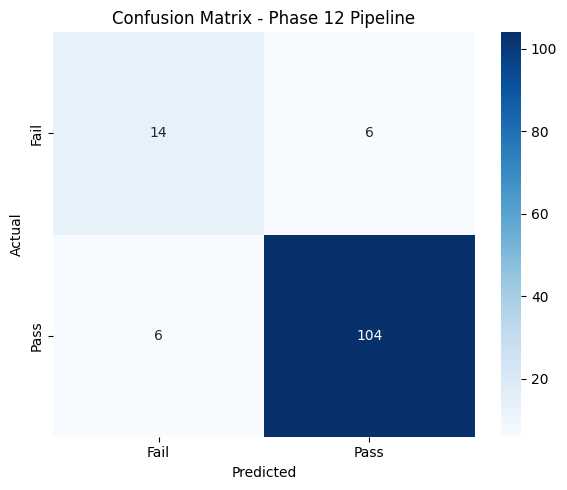

In [61]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)
plt.title("Confusion Matrix - Phase 12 Pipeline")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ***11.4. Precision-Recall curve***

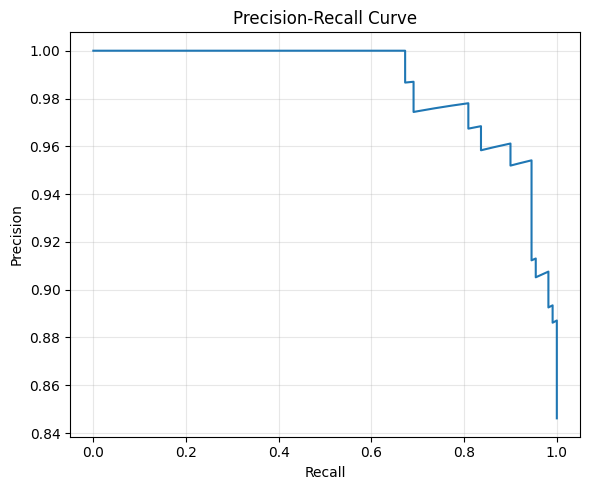

PR-AUC = 0.9861


In [62]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PR-AUC = {pr_auc:.4f}")

# ***11.5. Lưu bảng metric ra CSV***

In [63]:
metrics_path = os.path.join(OUTPUT_TABLE_DIR, "phase12_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)

print("Đã lưu metrics tại:", metrics_path)

Đã lưu metrics tại: outputs/tables/phase12_metrics.csv


# **12. Bảng Dự Đoán Chi Tiết**

In [66]:
results_test = X_test_raw.copy()
results_test["actual"] = y_test.values
results_test["pred_proba_pass"] = y_proba
results_test["pred_label"] = y_pred

results_test["actual_name"] = results_test["actual"].map({0: "Fail", 1: "Pass"})
results_test["pred_name"] = results_test["pred_label"].map({0: "Fail", 1: "Pass"})

results_test["error_type"] = "Correct"
results_test.loc[(results_test["actual"] == 0) & (results_test["pred_label"] == 1), "error_type"] = "False Positive"
results_test.loc[(results_test["actual"] == 1) & (results_test["pred_label"] == 0), "error_type"] = "False Negative"

display(results_test.head())

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,health,absences,G1,G2,actual,pred_proba_pass,pred_label,actual_name,pred_name,error_type
28,GP,M,16,U,LE3,A,3,4,services,other,...,5,2,12,12,1,0.996390,1,Pass,Pass,Correct
124,GP,F,16,U,GT3,T,2,2,other,other,...,5,0,12,11,1,0.990611,1,Pass,Pass,Correct
135,GP,F,16,U,GT3,A,3,4,services,other,...,5,12,15,13,1,0.999933,1,Pass,Pass,Correct
641,MS,F,18,R,GT3,T,2,2,at_home,other,...,4,0,14,17,1,0.999998,1,Pass,Pass,Correct
552,MS,M,19,U,GT3,T,1,1,other,other,...,4,2,9,9,1,0.272976,0,Pass,Fail,False Negative


Các mẫu dự đoán sai:

In [73]:
wrong_preds = results_test[results_test["error_type"] != "Correct"].copy()

print("Số mẫu dự đoán sai:", wrong_preds.shape[0], "/",y_test.shape[0], "mẫu")
display(wrong_preds.head(10))

Số mẫu dự đoán sai: 12 / 130 mẫu


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,health,absences,G1,G2,actual,pred_proba_pass,pred_label,actual_name,pred_name,error_type
552,MS,M,19,U,GT3,T,1,1,other,other,...,4,2,9,9,1,0.272976,0,Pass,Fail,False Negative
254,GP,F,18,U,LE3,T,2,2,at_home,services,...,5,16,9,8,1,0.321495,0,Pass,Fail,False Negative
52,GP,M,15,U,LE3,A,4,2,health,health,...,5,4,10,9,0,0.981514,1,Fail,Pass,False Positive
578,MS,M,17,U,GT3,T,3,3,health,other,...,3,4,8,9,1,0.325459,0,Pass,Fail,False Negative
487,MS,F,18,R,LE3,A,3,2,other,other,...,2,6,7,9,1,0.110866,0,Pass,Fail,False Negative
443,MS,M,15,R,LE3,T,4,1,health,services,...,2,7,7,9,0,0.530357,1,Fail,Pass,False Positive
81,GP,M,15,U,GT3,T,2,3,other,other,...,5,2,10,9,0,0.776599,1,Fail,Pass,False Positive
557,MS,F,17,R,GT3,T,3,1,other,other,...,5,2,7,9,1,0.029108,0,Pass,Fail,False Negative
642,MS,F,17,U,GT3,T,4,3,teacher,other,...,1,0,6,9,1,0.268711,0,Pass,Fail,False Negative
588,MS,F,17,U,GT3,T,4,1,health,at_home,...,5,0,8,10,0,0.978316,1,Fail,Pass,False Positive


,Error Type,Count
0,Correct,118
1,False Negative,6
2,False Positive,6


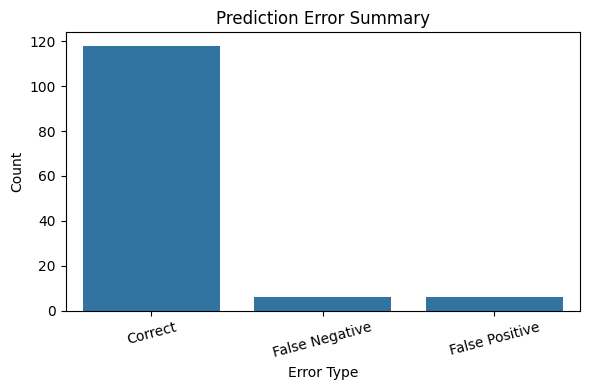

In [74]:
error_summary = results_test["error_type"].value_counts().reset_index()
error_summary.columns = ["Error Type", "Count"]

display(error_summary)

plt.figure(figsize=(6, 4))
sns.barplot(data=error_summary, x="Error Type", y="Count")
plt.title("Prediction Error Summary")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# **13. Trích Xuất Tên Feature Sau OneHotEncoding**

In [75]:
feature_names = model_pipeline.named_steps["preprocessor"].get_feature_names_out()

print("Tổng số feature sau preprocessing:", len(feature_names))
print("10 feature đầu tiên:")
print(feature_names[:10])

Tổng số feature sau preprocessing: 58
10 feature đầu tiên:
['num__age' 'num__Medu' 'num__Fedu' 'num__traveltime' 'num__studytime'
 'num__failures' 'num__famrel' 'num__freetime' 'num__goout' 'num__Dalc']


# **14. Phân Tích Hệ Số Logistic Regression**

In [76]:
coefficients = model_pipeline.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["abs_coef"] = coef_df["coefficient"].abs()

top_positive = coef_df.sort_values("coefficient", ascending=False).head(15)
top_negative = coef_df.sort_values("coefficient", ascending=True).head(15)

print("Top feature làm tăng khả năng PASS:")
display(top_positive[["feature", "coefficient"]])

print("Top feature làm giảm khả năng PASS:")
display(top_negative[["feature", "coefficient"]])

Top feature làm tăng khả năng PASS:


,feature,coefficient
14,num__G2,2.893719
13,num__G1,1.903455
15,cat__school_GP,0.784986
30,cat__Fjob_at_home,0.778355
26,cat__Mjob_health,0.629194
0,num__age,0.609120
38,cat__reason_reputation,0.456626
53,cat__higher_yes,0.431541
56,cat__romantic_no,0.358468
39,cat__guardian_father,0.336919


Top feature làm giảm khả năng PASS:


,feature,coefficient
16,cat__school_MS,-0.786605
33,cat__Fjob_services,-0.578143
32,cat__Fjob_other,-0.568696
52,cat__higher_no,-0.433160
28,cat__Mjob_services,-0.418718
5,num__failures,-0.410874
57,cat__romantic_yes,-0.360087
2,num__Fedu,-0.335262
40,cat__guardian_mother,-0.315453
35,cat__reason_course,-0.301844


Visualize top feature quan trọng:

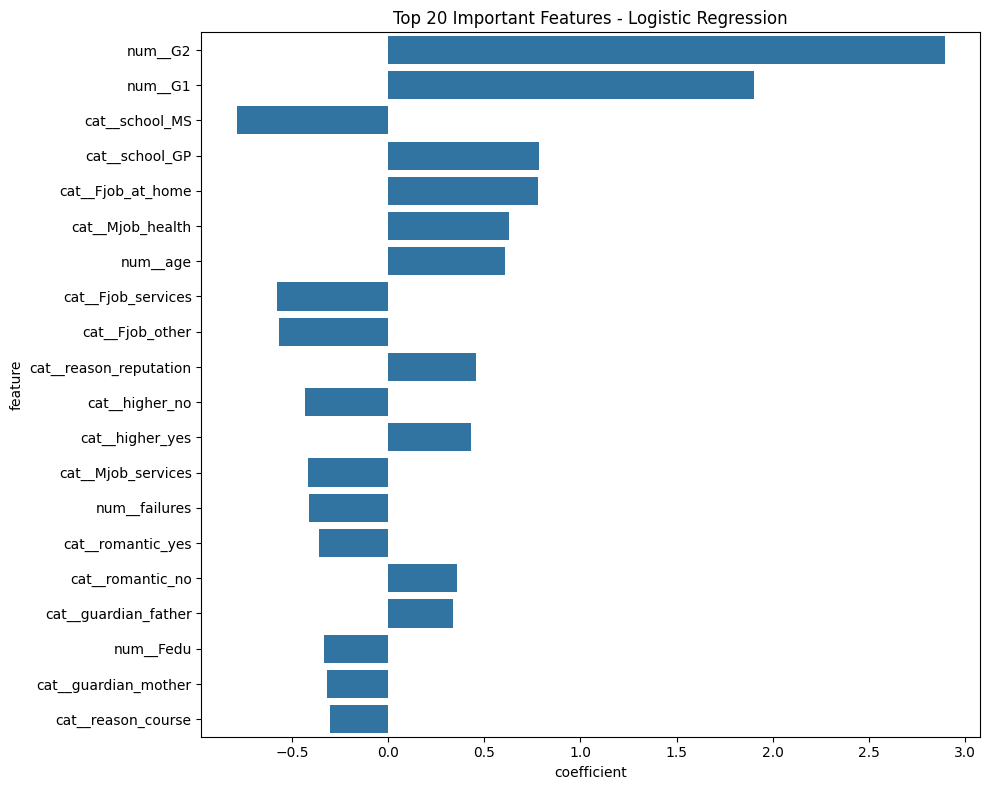

In [77]:
top_features = coef_df.sort_values("abs_coef", ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_features, x="coefficient", y="feature")
plt.title("Top 20 Important Features - Logistic Regression")
plt.tight_layout()
plt.show()

# **15. Hàm Dự Đoán Cho Sinh Viên Mới**

In [79]:
def predict_student_risk(student_dict, pipeline=model_pipeline, threshold=0.5):
    """
    student_dict: dict có cùng schema với X_raw
    pipeline: sklearn pipeline đã huấn luyện
    threshold: ngưỡng phân lớp

    return: dict kết quả dự đoán
    """
    student_df = pd.DataFrame([student_dict])
    proba_pass = pipeline.predict_proba(student_df)[:, 1][0]
    pred_pass = int(proba_pass >= threshold)

    return {
        "probability_pass": round(float(proba_pass), 4),
        "probability_fail": round(float(1 - proba_pass), 4),
        "predicted_label": "Pass" if pred_pass == 1 else "Fail"
    }

Test:

In [88]:
# Lấy 1 mẫu từ tập test
sample_student = X_test_raw.iloc[0]
sample_dict = sample_student.to_dict()

# Lấy index của mẫu
idx = X_test_raw.index[0]

# Nhãn thật
actual_label = y_test.loc[idx]
actual_name = "Pass" if actual_label == 1 else "Fail"

# Dự đoán
sample_result = predict_student_risk(
    student_dict=sample_dict,
    pipeline=model_pipeline,
    threshold=THRESHOLD
)

# Hiển thị
print("\nDữ liệu input")
items = [f"{{{k}: {v}}}" for k, v in sample_dict.items()]

for i in range(0, len(items), 5):
    print("; ".join(items[i:i+5]))

print("\nDữ liệu output (predict)")
print(f"Xác suất PASS: {sample_result['probability_pass']:.4f}")
print(f"Xác suất FAIL: {sample_result['probability_fail']:.4f}")
print(f"Kết luận: {sample_result['predicted_label']}")
print("Actual (thực tế):", actual_name)


Dữ liệu input
{school: GP}; {sex: M}; {age: 16}; {address: U}; {famsize: LE3}
{Pstatus: A}; {Medu: 3}; {Fedu: 4}; {Mjob: services}; {Fjob: other}
{reason: home}; {guardian: mother}; {traveltime: 1}; {studytime: 2}; {failures: 0}
{schoolsup: yes}; {famsup: yes}; {paid: yes}; {activities: yes}; {nursery: yes}
{higher: yes}; {internet: yes}; {romantic: no}; {famrel: 5}; {freetime: 3}
{goout: 3}; {Dalc: 1}; {Walc: 1}; {health: 5}; {absences: 2}
{G1: 12}; {G2: 12}

Dữ liệu output (predict)
Xác suất PASS: 0.9964
Xác suất FAIL: 0.0036
Kết luận: Pass
Actual (thực tế): Pass


Xuất file .joblib:

In [89]:
pipeline_path = os.path.join(OUTPUT_MODEL_DIR, "student_pass_fail_pipeline.joblib")
joblib.dump(model_pipeline, pipeline_path)

print("Đã lưu pipeline tại:", pipeline_path)

Đã lưu pipeline tại: outputs/models/student_pass_fail_pipeline.joblib


Lưu metadata:

In [90]:
metadata = {
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "threshold": THRESHOLD,
    "target_definition": "pass = 1 if G3 >= 10 else 0",
    "dropped_columns": ["G3"],
    "numeric_features": numeric_features,
    "categorical_features": categorical_features
}

metadata_path = os.path.join(OUTPUT_MODEL_DIR, "student_pass_fail_pipeline_metadata.json")

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

print("Đã lưu metadata tại:", metadata_path)

Đã lưu metadata tại: outputs/models/student_pass_fail_pipeline_metadata.json


Kiểm tra load lại pipeline:

In [91]:
loaded_pipeline = joblib.load(pipeline_path)

loaded_result = predict_student_risk(
    student_dict=sample_student,
    pipeline=loaded_pipeline,
    threshold=THRESHOLD
)

print("Kết quả khi load lại pipeline:")
print(loaded_result)

Kết quả khi load lại pipeline:
{'probability_pass': 0.9964, 'probability_fail': 0.0036, 'predicted_label': 'Pass'}


# **Kết Luận**

In [92]:
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")
print("\nPipeline saved successfully.")

Accuracy : 0.9077
Precision: 0.9455
Recall   : 0.9455
F1-score : 0.9455
PR-AUC   : 0.9861

Pipeline saved successfully.
